In [1]:
from pathlib import Path
import uproot 
import numpy as np
import awkward as ak
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data_path = Path("/pscratch/sd/h/hrzhao/Dataset/outreach/samples")

In [3]:
sig_H5pp_m300 = data_path / "signal_H5pp" / "H5pp_m300_525929" / "mc20a"
assert sig_H5pp_m300.exists(), f"Path {sig_H5pp_m300} does not exist"

bkg_ssWW_EW = data_path / "bkg_H5pp" / "ssWW_EW_700590/" / "mc20a" / "user.jmcgowan.42020815._000001.ANALYSIS.root"
assert bkg_ssWW_EW.exists(), f"Path {bkg_ssWW_EW} does not exist"

In [4]:
sig_H5pp_m300 = uproot.open(sig_H5pp_m300)
print(sig_H5pp_m300.keys())

bkg_ssWW_EW = uproot.open(bkg_ssWW_EW)
print(bkg_ssWW_EW.keys())

['defaultTree;1']
['defaultTree;1']


In [5]:
sig_H5pp_m300_tree = sig_H5pp_m300["defaultTree;1"]
bkg_ssWW_EW_tree = bkg_ssWW_EW["defaultTree;1"]

In [6]:
all_nominal_branch_names_signal = sig_H5pp_m300_tree.keys(filter_name='*_NOSYS')
all_weight_names_signal = sig_H5pp_m300_tree.keys(filter_name='*weight*_NOSYS')

all_nominal_branch_names_background = bkg_ssWW_EW_tree.keys(filter_name='*_NOSYS')
all_weight_names_background = bkg_ssWW_EW_tree.keys(filter_name='*weight*_NOSYS')

In [7]:
len(all_nominal_branch_names_signal)
len(all_nominal_branch_names_background)

# print the different branches
set(all_nominal_branch_names_signal) - set(all_nominal_branch_names_background)

{'jet_rap_NOSYS',
 'pass_ee_NOSYS',
 'pass_em_NOSYS',
 'pass_me_NOSYS',
 'pass_mm_NOSYS'}

In [8]:
set(all_weight_names_signal) - set(all_weight_names_background)

set()

In [9]:
# write out all_nominal_branch_names 
with open("all_nominal_branch_names_ssWW_signal.txt", "w") as f:
    for branch in all_nominal_branch_names_signal:
        f.write(f"{branch}\n")

with open("all_nominal_branch_names_ssWW_background.txt", "w") as f:
    for branch in all_nominal_branch_names_background:
        f.write(f"{branch}\n")


In [10]:
# print the first 10 branch names
print(all_nominal_branch_names_signal[:10])

# print the weight names
print(all_weight_names_signal)

['Et_ll_NOSYS', 'H_t_NOSYS', 'MT_dilep_NOSYS', 'MT_trilep_NOSYS', 'weight_pileup_NOSYS', 'RNNScore_NOSYS', 'bjet_n_NOSYS', 'dEta_jj_NOSYS', 'dPhi_jj_NOSYS', 'dPhi_ll_NOSYS']
['weight_pileup_NOSYS', 'weight_fjvt_effSF_NOSYS', 'weight_mc_NOSYS', 'weight_jvt_effSF_NOSYS']


In [11]:
# define the baseline criteria
WW_baseline = "pass_WW_baseline_NOSYS"

sig_specific_features = [    
    "pass_ee_NOSYS", "pass_mm_NOSYS", "pass_em_NOSYS", "pass_me_NOSYS", 
    ]

# choose several branches to plot
selected_features = [
    "el_n_NOSYS", "mu_n_NOSYS", "jet_n_NOSYS", "bjet_n_NOSYS",
    "el_WW_selected_NOSYS", "mu_WW_selected_NOSYS", 
    "mu_pt_NOSYS", "mu_z0sinth_NOSYS", "mu_d0_NOSYS", "mu_d0sig_NOSYS", "mu_select_Medium_NOSYS", "mu_select_PflowTight_VarRad_NOSYS", # no mu_eta, for SR selection due to bugs
    "el_e_NOSYS", "el_d0_NOSYS", "el_z0_NOSYS",
    "jet_e_NOSYS", "jet_pt_NOSYS", "jet1_pt_NOSYS", "jet2_pt_NOSYS",
    "mjj_NOSYS", "dEta_jj_NOSYS", "Et_ll_NOSYS", "H_t_NOSYS", "MT_dilep_NOSYS", "pt_ll_NOSYS", "mll_NOSYS"
    ]
weights = ["weight_mc_NOSYS"]

In [12]:
# load the data into a awkward array
sig_H5pp_m300_features = sig_H5pp_m300_tree.arrays([WW_baseline] + sig_specific_features + selected_features + weights, library="ak")
sig_H5pp_m300_features = sig_H5pp_m300_features[sig_H5pp_m300_features[WW_baseline] == 1]

bkg_WZ_QCD_features = bkg_ssWW_EW_tree.arrays([WW_baseline] + selected_features + weights, library="ak")
bkg_WZ_QCD_features = bkg_WZ_QCD_features[bkg_WZ_QCD_features[WW_baseline] == 1]

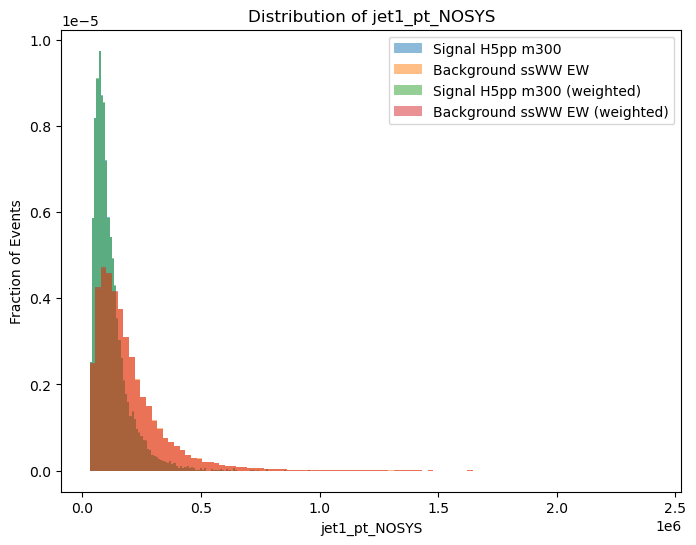

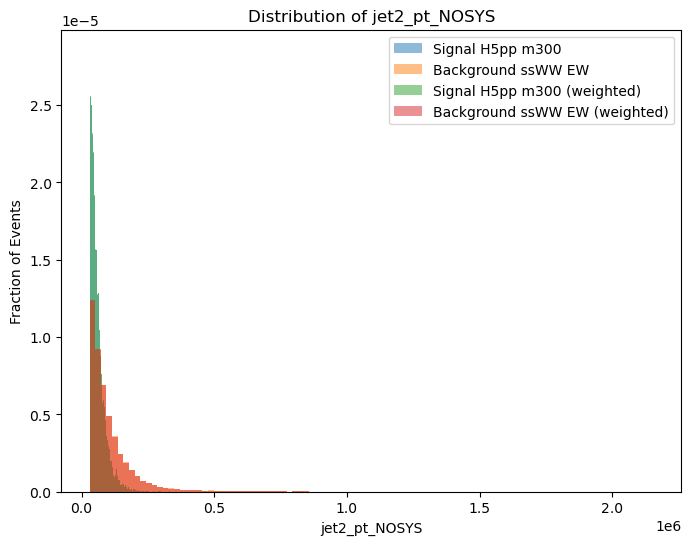

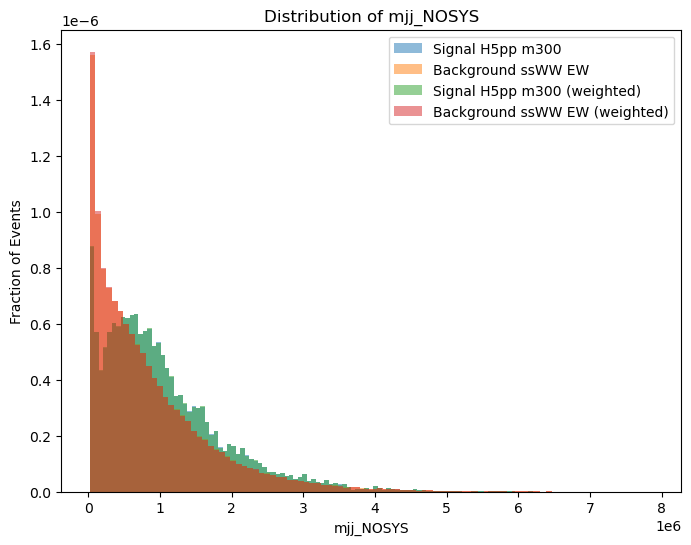

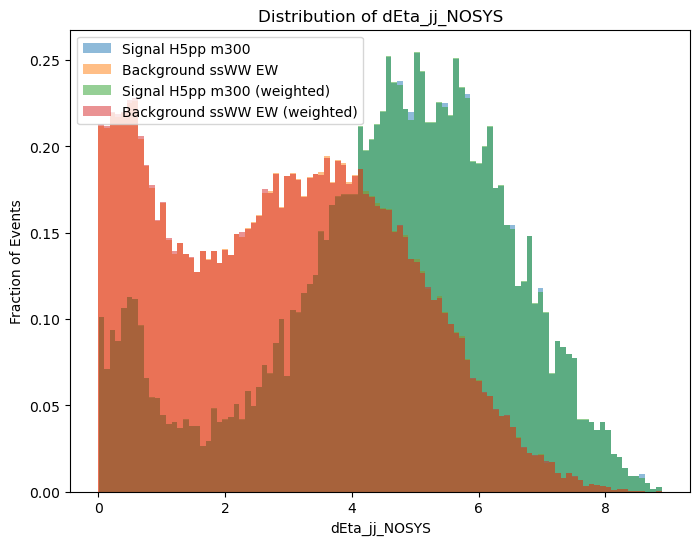

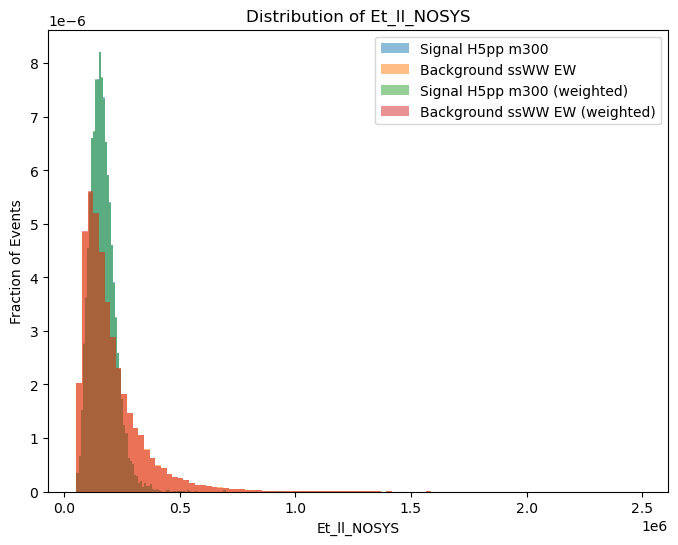

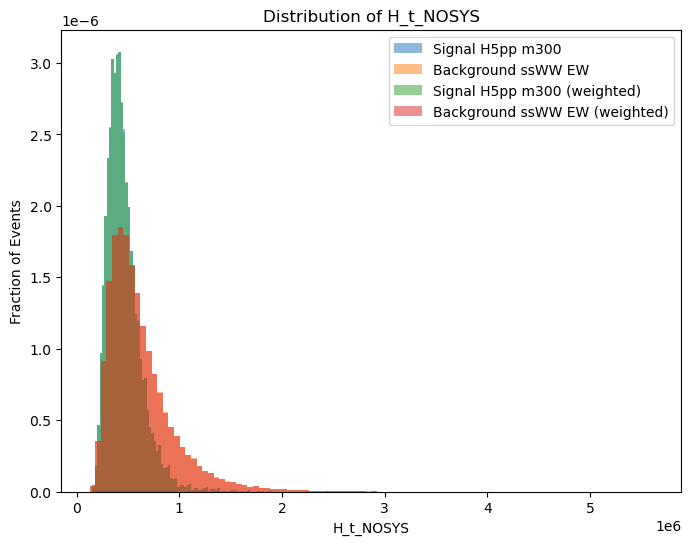

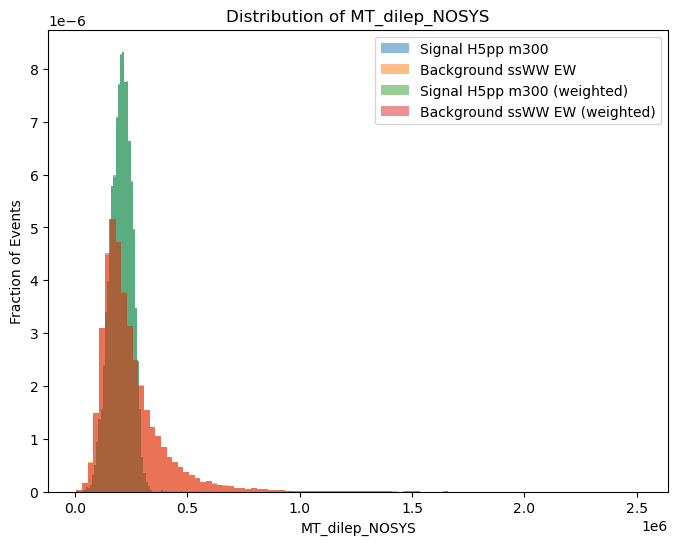

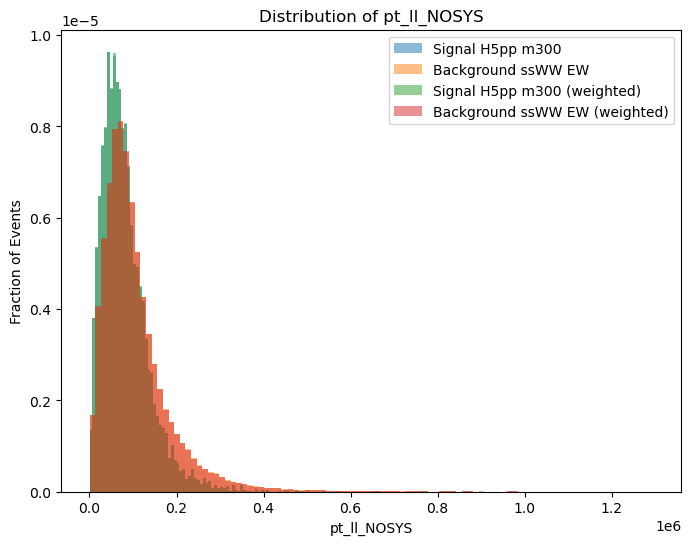

In [13]:
# for each feature, plot the distribution for signal and background w/ and w/o event weights 
for feature in selected_features[-9:-1]:
    plt.figure(figsize=(8, 6))
    plt.hist(sig_H5pp_m300_features[feature], bins=100, alpha=0.5, label="Signal H5pp m300", density=True)
    plt.hist(bkg_WZ_QCD_features[feature], bins=100, alpha=0.5, label="Background ssWW EW", density=True)

    plt.hist(sig_H5pp_m300_features[feature], weights=sig_H5pp_m300_features["weight_mc_NOSYS"], bins=100, alpha=0.5, label="Signal H5pp m300 (weighted)", density=True)
    plt.hist(bkg_WZ_QCD_features[feature], weights=bkg_WZ_QCD_features["weight_mc_NOSYS"], bins=100, alpha=0.5, label="Background ssWW EW (weighted)", density=True)

    plt.xlabel(feature)
    plt.ylabel("Fraction of Events")
    plt.title(f"Distribution of {feature}")
    plt.legend()
    plt.show()

In [14]:
def apply_signal_region_cuts(features):
    # 1. baseline lepton selection
    cut_baseline_lep = (
        (ak.num(features["el_WW_selected_NOSYS"]) + ak.num(features["mu_WW_selected_NOSYS"])) > 0
    )

    # 2. 3 lepton veto
    cut_3lep_veto = (
        (features['el_n_NOSYS'] + features['mu_n_NOSYS']) < 3
    )

    # 3. exactly 2 leptons
    cut_2lep = (
        (features['el_n_NOSYS'] + features['mu_n_NOSYS']) == 2
    )

    ### 2 electrons 
    ### due to the missing branch, TODO: both electron eta < 1.37 
    # cut_2el_eta = (
    #     cut_2el & 
    #     (np.abs(sig_H5pp_m300_features['el_eta_NOSYS'][:, 0]) < 1.37) & 
    #     (np.abs(sig_H5pp_m300_features['el_eta_NOSYS'][:, 1]) < 1.37)
    # )

    # cut_sig_lep = ak.where(
    #     cut_2el,
    #     cut_2el_eta,  # if 2 electron, check eta
    #     True          # else (not 2el), pass
    # )

    ### same sign requirement 
    ### due to the missing branch, TODO: abs(charge1+charge2) == 2
    # el_charge_sum = ak.sum(sig_H5pp_m300_features['el_charge_NOSYS'], axis=1)
    # mu_charge_sum = ak.sum(sig_H5pp_m300_features['mu_charge_NOSYS'], axis=1)
    # lep_charge_sum = el_charge_sum + mu_charge_sum
    # cut_SS = np.abs(lep_charge_sum) == 2

    # 4. mll > 20 GeV
    cut_mll = features['mll_NOSYS'] > 20_000

    # 5. Z peak removal (only for 2 electrons)
    cut_2el = features['el_n_NOSYS'] == 2
    cut_Zpeak_removal = ak.where(
        cut_2el,
        np.abs(features['mll_NOSYS'] - 91187.6) > 15_000,
        True
    )

    # 6. Jet requirement
    cut_jet_req = (
        (features['jet_n_NOSYS'] > 1) &
        (features['jet1_pt_NOSYS'] > 65_000) &
        (features['jet2_pt_NOSYS'] > 35_000)
    )

    # Final combined cut
    final_cut = (
        cut_baseline_lep &
        cut_3lep_veto &
        cut_2lep &
        cut_mll &
        cut_Zpeak_removal &
        cut_jet_req
    )

    return features[final_cut]

In [19]:
print(f"Before applying signal region cuts: {len(sig_H5pp_m300_features)}")
sig_H5pp_m300_features_SR = apply_signal_region_cuts(sig_H5pp_m300_features)
print(f"After applying signal region cuts: {len(sig_H5pp_m300_features_SR)}")


print(f"Before applying signal region cuts: {len(bkg_WZ_QCD_features)}")
bkg_WZ_QCD_features_SR = apply_signal_region_cuts(bkg_WZ_QCD_features)
print(f"After applying signal region cuts: {len(bkg_WZ_QCD_features_SR)}")

Before applying signal region cuts: 8893
After applying signal region cuts: 6058
Before applying signal region cuts: 67448
After applying signal region cuts: 54678


In [22]:
print(f"significance = N_signal / sqrt(N_background)")
print(f"significance before = {ak.sum(sig_H5pp_m300_features['weight_mc_NOSYS']) / np.sqrt(ak.sum(bkg_WZ_QCD_features['weight_mc_NOSYS']))}")
print(f"significance after = {ak.sum(sig_H5pp_m300_features_SR['weight_mc_NOSYS']) / np.sqrt(ak.sum(bkg_WZ_QCD_features_SR['weight_mc_NOSYS']))}")

significance = N_signal / sqrt(N_background)
significance before = 0.020572545006871223
significance after = 0.015559337101876736


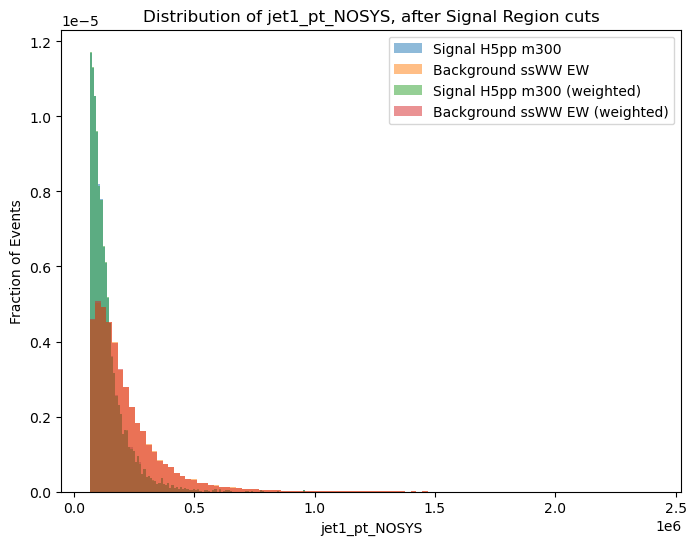

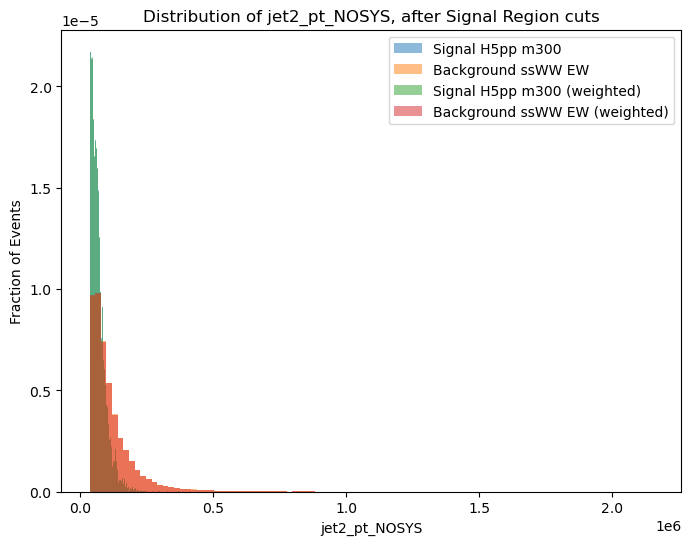

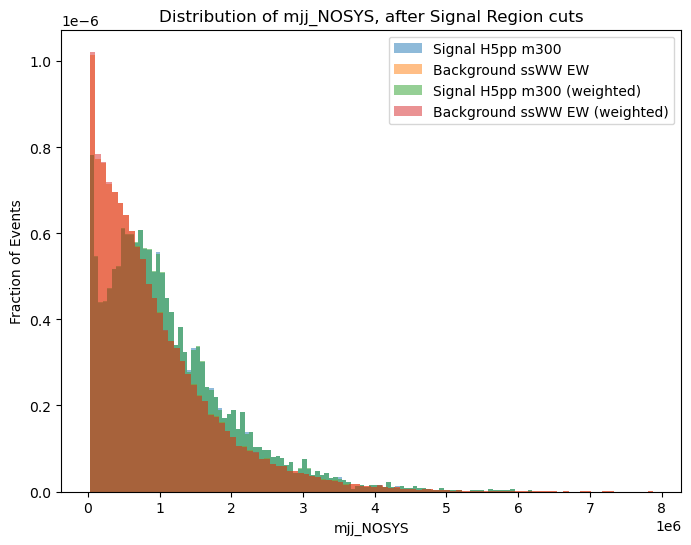

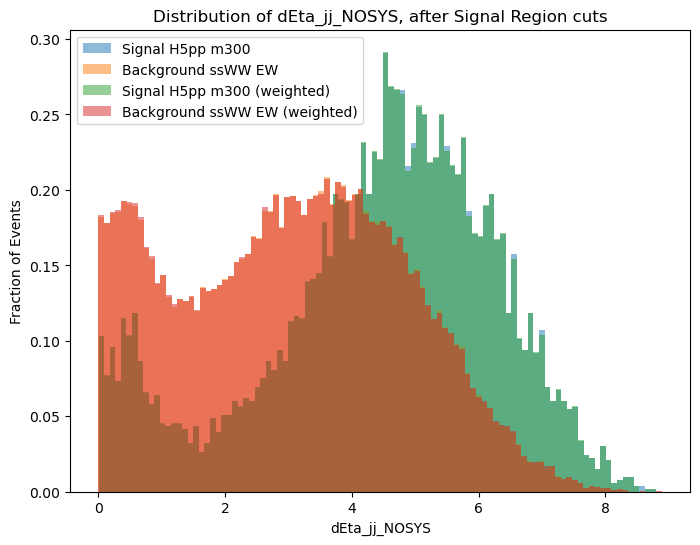

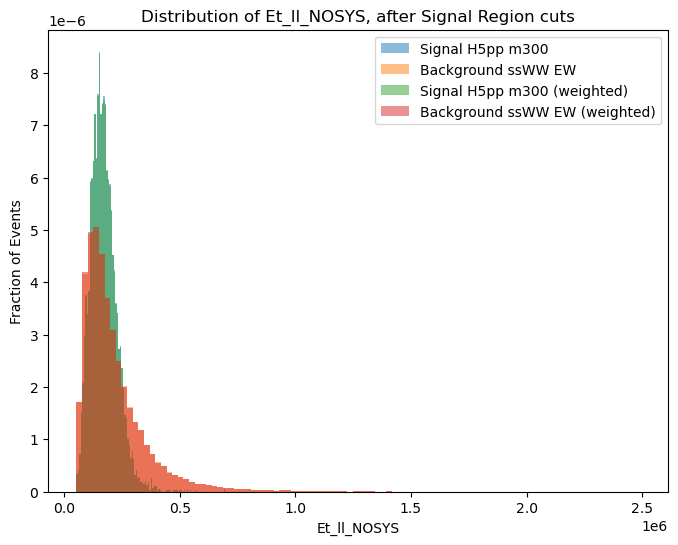

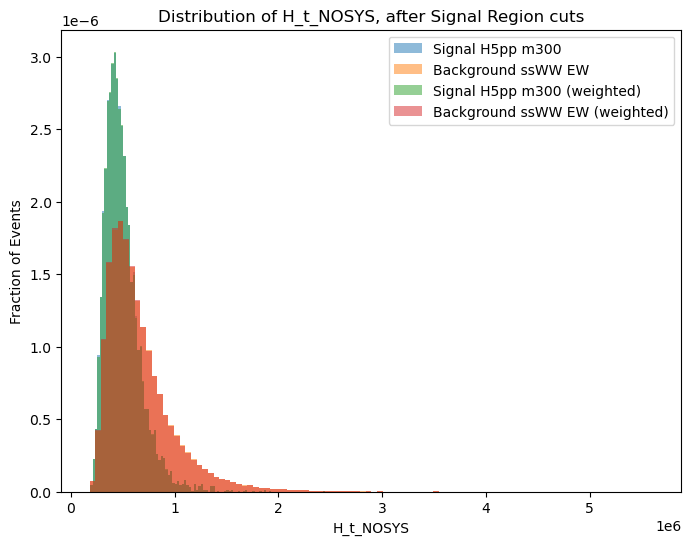

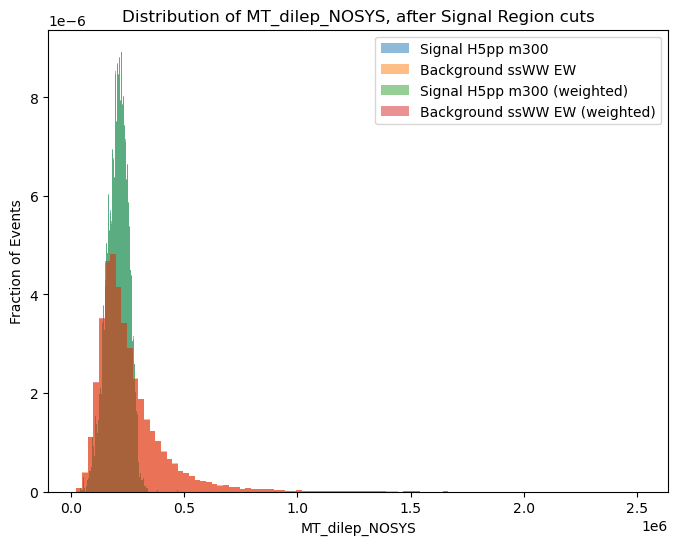

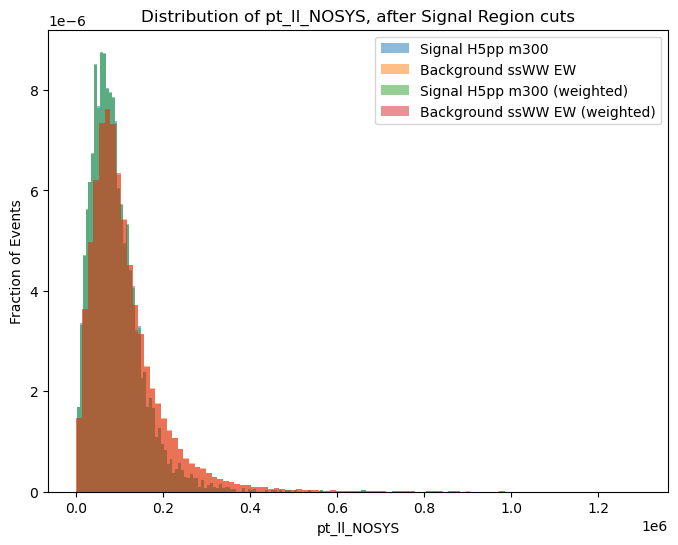

In [16]:
# for each feature, plot the distribution for signal and background w/ and w/o event weights 
for feature in selected_features[-9:-1]:
    plt.figure(figsize=(8, 6))
    plt.hist(sig_H5pp_m300_features_SR[feature], bins=100, alpha=0.5, label="Signal H5pp m300", density=True)
    plt.hist(bkg_WZ_QCD_features_SR[feature], bins=100, alpha=0.5, label="Background ssWW EW", density=True)

    plt.hist(sig_H5pp_m300_features_SR[feature], weights=sig_H5pp_m300_features_SR["weight_mc_NOSYS"], bins=100, alpha=0.5, label="Signal H5pp m300 (weighted)", density=True)
    plt.hist(bkg_WZ_QCD_features_SR[feature], weights=bkg_WZ_QCD_features_SR["weight_mc_NOSYS"], bins=100, alpha=0.5, label="Background ssWW EW (weighted)", density=True)

    plt.xlabel(feature)
    plt.ylabel("Fraction of Events")
    plt.title(f"Distribution of {feature}, after Signal Region cuts")
    plt.legend()
    plt.show()